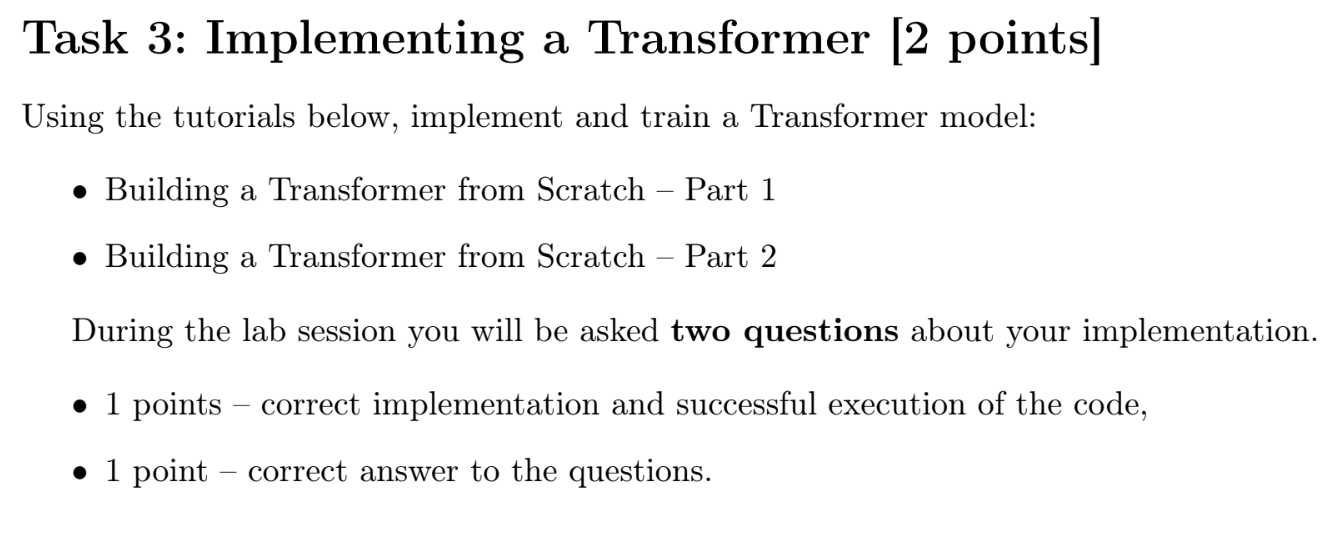

In [ ]:
import torch
import torch.nn as nn
import math

class InputEmbeddings(nn.Module):
    def __init__(self, d, vocab_size):
        ''' 
        d - wymiarowość embeddingów 
        vocab_size - ilość wszystkich tokenów w słowniku
        '''
        super().__init__()
        self.d = d
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d)
    
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d)
    
class PositionalEncoding(nn.Module):
    ''' 
    Tworzymy wektor odpowiedzialny za informowanie o pozycji tokena w kontekście
    d - wymiarowość 
    max_len - maksymalna długość sekwencji na wejściu 
    dropout - rate, czyli z jakim ppb odrzucamy jakieś neurony podczas treningu - regularyzacja
    '''
    def __init__(self, d, max_len, dropout):
        super().__init__()
        self.d = d
        self.max_len = max_len
        self.dropout = nn.Dropout(dropout)
        
        pe = torch.zeros(max_len, d)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # (seq, 1)
        
        div_term = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d)) # (d / 2)
        
        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term) 
        
        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term) 
        
        # Add a batch dimension to the positional encoding
        pe = pe.unsqueeze(0) # (1, seq, d_model)
        
        # Register the positional encoding as a buffer
        # Jest nam to potrzebne aby nie przekazywać w ogóle tych encodingów do optymalizatora,
        # ale jednak aby zostały one zapisane w modelu 
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Dodajemy ten encoding do wektora x, ale nie chcemy ich aktualizować podczas uczenia
        x = x + (self.pe[:, :x.shape[1], :]).requires_grad_(False) # (batch, seq, d_model)
        return self.dropout(x) # aplikujemy dropout
    
class LayerNormalization(nn.Module):
    # Normalizacja 
    def __init__(self, no_of_features, eps=10**-6):
        """ 
        no_of_features - liczba cech x
        eps - mała wartość aby nie było potem dzielenia przez zero
        w - wagi 
        b - biasy 
        """
        super().__init__()
        self.eps = eps
        self.w = nn.Parameter(torch.ones(no_of_features)) 
        self.b = nn.Parameter(torch.zeros(no_of_features)) 

    def forward(self, x):
        # x: (batch, seq, hidden_size)
        # Keep the dimension for broadcasting
        mean = x.mean(dim = -1, keepdim = True) # (batch, seq, 1)
        # Keep the dimension for broadcasting
        std = x.std(dim = -1, keepdim = True) # (batch, seq, 1)
        # eps is to prevent dividing by zero or when std is very small
        return self.w * (x - mean) / (std + self.eps) + self.b
    
class FeedForwardBlock(nn.Module):
    ''' 
    Pierwsze dwie warstwy fully connected 
    '''
    def __init__(self, d: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear_1 = nn.Linear(d, d_ff) # w1 and b1
        self.dropout = nn.Dropout(dropout)
        self.linear_2 = nn.Linear(d_ff, d) # w2 and b2

    def forward(self, x):
        # (batch, seq, d_model) --> (batch, seq, d_ff) --> (batch, seq, d_model)
        return self.linear_2(self.dropout(torch.relu(self.linear_1(x))))
    
class MultiHeadAttentionBlock(nn.Module):
    ''' 
    Robimy wiele głów attention, każda głowa procesuje jakiś fragment wektorów 
    '''
    def __init__(self, d, no_of_heads, dropout):
        super().__init__()
        self.d = d # Embedding vector size
        self.no_of_heads = no_of_heads # Number of heads
        # Make sure d is divisible by h - musimy ładnie podzielić zadania na głowy i to zrównoleglić
        assert d % no_of_heads == 0, "d is not divisible by h"

        self.d_k = d // no_of_heads # Dimension of vector seen by each head
        self.w_q = nn.Linear(d, d, bias=False) # Wq
        self.w_k = nn.Linear(d, d, bias=False) # Wk
        self.w_v = nn.Linear(d, d, bias=False) # Wv
        self.w_o = nn.Linear(d, d, bias=False) # Wo - wagi outputu
        self.dropout = nn.Dropout(dropout)

    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        # Just apply the formula from the paper
        # (batch, h, seq, d_k) --> (batch, h, seq, seq)
        attention_scores = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            # Write a very low value (indicating -inf) to the positions where mask == 0
            # Masking - pod przekątną dajemy bardzo niskie wartości, aby po softmaxie
            # pojawiły się tam zera - aby tokeny późniejsze nie wpływały na wcześniejsze  
            # podczas treningu 
            attention_scores.masked_fill_(mask == 0, -1e9)
        attention_scores = attention_scores.softmax(dim=-1) # (batch, h, seq, seq) # Apply softmax
        if dropout is not None:
            attention_scores = dropout(attention_scores)
        # (batch, h, seq, seq) --> (batch, h, seq, d_k)
        # return attention scores which can be used for visualization
        return (attention_scores @ value), attention_scores

    def forward(self, q, k, v, mask):
        query = self.w_q(q) # (batch, seq, d_model) --> (batch, seq, d_model)
        key = self.w_k(k) # (batch, seq, d_model) --> (batch, seq, d_model)
        value = self.w_v(v) # (batch, seq, d_model) --> (batch, seq, d_model)

        # (batch, seq, d_model) --> (batch, seq, h, d_k) --> (batch, h, seq, d_k)
        # Ta zmiana jest potrzebna aby rozdzielić te wektory na kilka głów 
        query = query.view(query.shape[0], query.shape[1], self.no_of_heads, self.d_k).transpose(1, 2)
        key = key.view(key.shape[0], key.shape[1], self.no_of_heads, self.d_k).transpose(1, 2)
        value = value.view(value.shape[0], value.shape[1], self.no_of_heads, self.d_k).transpose(1, 2)

        # Calculate attention
        x, self.attention_scores = MultiHeadAttentionBlock.attention(query, key, value, mask, self.dropout)
        
        # Combine all the heads together
        # (batch, h, seq, d_k) --> (batch, seq, h, d_k) --> (batch, seq, d_model)
        # łączymy wyniki z każdej głowy do oryginalnego rozmiaru
        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.no_of_heads * self.d_k)

        # Multiply by Wo
        # (batch, seq, d_model) --> (batch, seq, d_model)  
        return self.w_o(x)
    
class ResidualConnection(nn.Module):
    """ 
    Residual connection dodaje to co przed warstwami do tego co z nich wychodzi 
    Pomaga to z problemem zanikającego/eksplodującego gradientu 
    Dodatkowo Taka sieć może łatwiej się nauczyć np. identyczności
    """
    def __init__(self, features, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization(features)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))
    
class EncoderBlock(nn.Module):
    """ 
    Encoder odpowiada za przekształcenie inputu w wielowymiarowy embedding,
    używamy do tego self attention mechanizmu - keys i query są kolumnami i wierszami 
    """
    def __init__(self, features: int, self_attention_block: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, dropout: float) -> None:
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        # dwie residual connections - jeden dla self attention a drugi dla feed forward
        self.residual_connections = nn.ModuleList([ResidualConnection(features, dropout) for _ in range(2)])

    def forward(self, x, src_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, src_mask))
        x = self.residual_connections[1](x, self.feed_forward_block)
        # Zwracamy tensor który przeszedł przez warstwy self attention 
        # oraz feed forward, oraz przy tym dwie RC
        return x
    
class Encoder(nn.Module):
    """ 
    Normalizujemy warstwa po warstwie wszystko w enkoder block
    """
    def __init__(self, features: int, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization(features)

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)
    
class DecoderBlock(nn.Module):

    def __init__(self, features, self_attention_block, cross_attention_block, feed_forward_block, dropout):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(features, dropout) for _ in range(3)])

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, tgt_mask))
        x = self.residual_connections[1](x, lambda x: self.cross_attention_block(x, encoder_output, encoder_output, src_mask))
        x = self.residual_connections[2](x, self.feed_forward_block)
        return x
    
class DecoderBlock(nn.Module):
    """ 
    Generujemy Query na bazie self attention, a potem stosujemy je 
    w cross attention gdzie key and value pochodzi od tego co wypluł encoder
    """
    def __init__(self, features, self_attention_block, cross_attention_block, feed_forward_block, dropout):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(features, dropout) for _ in range(3)])

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, tgt_mask))
        x = self.residual_connections[1](x, lambda x: self.cross_attention_block(x, encoder_output, encoder_output, src_mask))
        x = self.residual_connections[2](x, self.feed_forward_block)
        return x
    
class Decoder(nn.Module):

    def __init__(self, features, layers):
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization(features)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)
    
class ProjectionLayer(nn.Module):
    """ 
    Mapuje wynik encodera na słowa ze słownika 
    """
    def __init__(self, d, vocab_size):
        super().__init__()
        self.proj = nn.Linear(d, vocab_size)

    def forward(self, x) -> None:
        # (batch, seq, d) --> (batch, seq, vocab_size)
        return self.proj(x)
    
class Transformer(nn.Module):

    def __init__(self, encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer) -> None:
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed # embedding wejścia 
        self.tgt_embed = tgt_embed # embedding targetu 
        self.src_pos = src_pos # positional encoding wejścia 
        self.tgt_pos = tgt_pos # positional encoding targetu
        self.projection_layer = projection_layer

    def encode(self, src, src_mask):
        # (batch, seq, d)
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)
    
    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        # (batch, seq, d)
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)
    
    def project(self, x):
        # (batch, seq, vocab_size)
        return self.projection_layer(x)
    
def build_transformer(src_vocab_size, tgt_vocab_size, src_seq, tgt_seq, d=512, N=6, no_of_heads=8, dropout=0.1, d_ff=2048):
    # Create the embedding layers
    src_embed = InputEmbeddings(d, src_vocab_size)
    tgt_embed = InputEmbeddings(d, tgt_vocab_size)

    # Create the positional encoding layers
    src_pos = PositionalEncoding(d, src_seq, dropout)
    tgt_pos = PositionalEncoding(d, tgt_seq, dropout)
    
    # Create the encoder blocks
    encoder_blocks = []
    for _ in range(N):
        encoder_self_attention_block = MultiHeadAttentionBlock(d, no_of_heads, dropout)
        feed_forward_block = FeedForwardBlock(d, d_ff, dropout)
        encoder_block = EncoderBlock(d, encoder_self_attention_block, feed_forward_block, dropout)
        encoder_blocks.append(encoder_block)

    # Create the decoder blocks
    decoder_blocks = []
    for _ in range(N):
        decoder_self_attention_block = MultiHeadAttentionBlock(d, no_of_heads, dropout)
        decoder_cross_attention_block = MultiHeadAttentionBlock(d, no_of_heads, dropout)
        feed_forward_block = FeedForwardBlock(d, d_ff, dropout)
        decoder_block = DecoderBlock(d, decoder_self_attention_block, decoder_cross_attention_block, feed_forward_block, dropout)
        decoder_blocks.append(decoder_block)
    
    # Create the encoder and decoder
    encoder = Encoder(d, nn.ModuleList(encoder_blocks))
    decoder = Decoder(d, nn.ModuleList(decoder_blocks))
    
    # Create the projection layer
    projection_layer = ProjectionLayer(d, tgt_vocab_size)
    
    # Create the transformer
    transformer = Transformer(encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer)
    
    # Initialize the parameters, jesteśmy gotowi do treningu
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    
    return transformer

# Trenowanie transformera

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    """ 
    Tworzymy dataset do tłumaczenia zdań 
    """
    def __init__(self, ds, tokenizer_src, tokenizer_tgt, src_lang, tgt_lang, seq_len):
        """ 
        ds - dataset, zawierający source i target text 
        tokenizer_src/_tgt - tokenizer dla wejścia i targetu 
        src_lang/tgt_lang - identyfikator języka (np. 'en' dla angielskiego)
        seq_len - długość sentencji do której fragmenty będą ucinane/paddowane
        """
        super().__init__()
        self.seq_len = seq_len

        self.ds = ds
        self.tokenizer_src = tokenizer_src
        self.tokenizer_tgt = tokenizer_tgt
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang
        # Start of Sentence token
        self.sos_token = torch.tensor([tokenizer_tgt.token_to_id("[SOS]")], dtype=torch.int64)
        # End of sentence toke n
        self.eos_token = torch.tensor([tokenizer_tgt.token_to_id("[EOS]")], dtype=torch.int64)
        # Padding token to make the sentences match in length
        self.pad_token = torch.tensor([tokenizer_tgt.token_to_id("[PAD]")], dtype=torch.int64)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        src_target_pair = self.ds[idx]
        src_text = src_target_pair['translation'][self.src_lang]
        tgt_text = src_target_pair['translation'][self.tgt_lang]

        # Transform the text into tokens
        enc_input_tokens = self.tokenizer_src.encode(src_text).ids
        dec_input_tokens = self.tokenizer_tgt.encode(tgt_text).ids

        # Add sos, eos and padding to each sentence
        enc_num_padding_tokens = self.seq_len - len(enc_input_tokens) - 2  # We will add <s> and </s>
        # We will only add <s>, and </s> only on the label
        dec_num_padding_tokens = self.seq_len - len(dec_input_tokens) - 1

        # Make sure the number of padding tokens is not negative. If it is, the sentence is too long
        if enc_num_padding_tokens < 0 or dec_num_padding_tokens < 0:
            raise ValueError("Sentence is too long")

        # Add <s> and </s> token
        encoder_input = torch.cat(
            [
                self.sos_token,
                torch.tensor(enc_input_tokens, dtype=torch.int64),
                self.eos_token,
                torch.tensor([self.pad_token] * enc_num_padding_tokens, dtype=torch.int64),
            ],
            dim=0,
        )

        # Add only <s> token
        decoder_input = torch.cat(
            [
                self.sos_token,
                torch.tensor(dec_input_tokens, dtype=torch.int64),
                torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype=torch.int64),
            ],
            dim=0,
        )

        # Add only </s> token
        label = torch.cat(
            [
                torch.tensor(dec_input_tokens, dtype=torch.int64),
                self.eos_token,
                torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype=torch.int64),
            ],
            dim=0,
        )

        # Double check the size of the tensors to make sure they are all seq long
        assert encoder_input.size(0) == self.seq_len
        assert decoder_input.size(0) == self.seq_len
        assert label.size(0) == self.seq_len

        return {
            "encoder_input": encoder_input,  # (seq)
            "decoder_input": decoder_input,  # (seq)
            "encoder_mask": (encoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int(), # (1, 1, seq)
            "decoder_mask": (decoder_input != self.pad_token).unsqueeze(0).int() & causal_mask(decoder_input.size(0)), # (1, seq) & (1, seq, seq),
            "label": label,  # (seq)
            "src_text": src_text,
            "tgt_text": tgt_text,
        }
    
def causal_mask(size):
    # Maska z jedynkami na przekątnej i ponad nią 
    mask = torch.triu(torch.ones((1, size, size)), diagonal=1).type(torch.int)
    return mask == 0

from pathlib import Path

def get_config():
    return {
        "batch_size": 8,
        "num_epochs": 5,
        "lr": 10**-4,
        "seq": 350,
        "d_model": 512,
        "datasource": 'opus_books',
        "lang_src": "en",
        "lang_tgt": "it",
        "model_folder": "weights",
        "model_basename": "tmodel_",
        "preload": "latest",
        "tokenizer_file": "tokenizer_{0}.json",
        "experiment_name": "runs/tmodel"
    }

def get_weights_file_path(config, epoch: str):
    model_folder = f"{config['datasource']}_{config['model_folder']}"
    model_filename = f"{config['model_basename']}{epoch}.pt"
    return str(Path('.') / model_folder / model_filename)

# Find the latest weights file in the weights folder
def latest_weights_file_path(config):
    model_folder = f"{config['datasource']}_{config['model_folder']}"
    model_filename = f"{config['model_basename']}*"
    weights_files = list(Path(model_folder).glob(model_filename))
    if len(weights_files) == 0:
        return None
    weights_files.sort()
    return str(weights_files[-1])

# from model import build_transformer
# from dataset import TranslationDataset, causal_mask
# from config import get_config, get_weights_file_path, latest_weights_file_path

import torchtext.datasets as datasets
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import LambdaLR

import warnings
from tqdm import tqdm
import os

# Huggingface datasets and tokenizers
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

import torchmetrics
from torch.utils.tensorboard import SummaryWriter

def get_all_sentences(ds, lang):
    """ 
    generator który zwraca wszystkie sentencje w danym języku 
    """
    for item in ds:
        yield item['translation'][lang]

def get_or_build_tokenizer(config, ds, lang):
    """ 
    Pobieramy zapisany tokenizer, albo tworzymy nowy
    """
    tokenizer_path = Path(config['tokenizer_file'].format(lang))
    if not Path.exists(tokenizer_path):
        # tworzymy tokenizer z modelem WordLevel, gdzie [UNK] to token na nieznane słowo
        tokenizer = Tokenizer(WordLevel(unk_token="[UNK]")) 
        tokenizer.pre_tokenizer = Whitespace()
        # 4 specjalne tokeny, a słowo musi pojawiać się >2 razy 
        trainer = WordLevelTrainer(special_tokens=["[UNK]", "[PAD]", "[SOS]", "[EOS]"], min_frequency=2)
        tokenizer.train_from_iterator(get_all_sentences(ds, lang), trainer=trainer)
        tokenizer.save(str(tokenizer_path))
    else:
        tokenizer = Tokenizer.from_file(str(tokenizer_path))
    return tokenizer

def get_ds(config):
    # It only has the train split, so we divide it overselves
    ds_raw = load_dataset(f"{config['datasource']}", f"{config['lang_src']}-{config['lang_tgt']}", split='train')

    # Build tokenizers
    tokenizer_src = get_or_build_tokenizer(config, ds_raw, config['lang_src'])
    tokenizer_tgt = get_or_build_tokenizer(config, ds_raw, config['lang_tgt'])

    # Keep 90% for training, 10% for validation
    train_ds_size = int(0.9 * len(ds_raw))
    val_ds_size = len(ds_raw) - train_ds_size
    train_ds_raw, val_ds_raw = random_split(ds_raw, [train_ds_size, val_ds_size])

    train_ds = TranslationDataset(train_ds_raw, tokenizer_src, tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq'])
    val_ds = TranslationDataset(val_ds_raw, tokenizer_src, tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq'])

    # Find the maximum length of each sentence in the source and target sentence
    max_len_src = 0
    max_len_tgt = 0

    for item in ds_raw:
        src_ids = tokenizer_src.encode(item['translation'][config['lang_src']]).ids
        tgt_ids = tokenizer_tgt.encode(item['translation'][config['lang_tgt']]).ids
        max_len_src = max(max_len_src, len(src_ids))
        max_len_tgt = max(max_len_tgt, len(tgt_ids))

    print(f'Max length of source sentence: {max_len_src}')
    print(f'Max length of target sentence: {max_len_tgt}')

    train_dataloader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True)
    val_dataloader = DataLoader(val_ds, batch_size=1, shuffle=True)

    return train_dataloader, val_dataloader, tokenizer_src, tokenizer_tgt

def get_model(config, vocab_src_len, vocab_tgt_len):
    model = build_transformer(vocab_src_len, vocab_tgt_len, config["seq"], config['seq'], d=config['d_model'])
    return model

def greedy_decode(model, source, source_mask, tokenizer_src, tokenizer_tgt, max_len, device):
    sos_idx = tokenizer_tgt.token_to_id('[SOS]')
    eos_idx = tokenizer_tgt.token_to_id('[EOS]')

    # Precompute the encoder output and reuse it for every step
    encoder_output = model.encode(source, source_mask)
    # Initialize the decoder input with the sos token
    decoder_input = torch.empty(1, 1).fill_(sos_idx).type_as(source).to(device)
    while True:
        if decoder_input.size(1) == max_len:
            break

        # build mask for target
        decoder_mask = causal_mask(decoder_input.size(1)).type_as(source_mask).to(device)

        # calculate output
        out = model.decode(encoder_output, source_mask, decoder_input, decoder_mask)

        # get next token
        prob = model.project(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        decoder_input = torch.cat(
            [decoder_input, torch.empty(1, 1).type_as(source).fill_(next_word.item()).to(device)], dim=1
        )

        if next_word == eos_idx:
            break

    return decoder_input.squeeze(0)

def run_validation(model, validation_ds, tokenizer_src, tokenizer_tgt, max_len, device, print_msg, global_step, writer, num_examples=2):
    model.eval()
    count = 0

    source_texts = []
    expected = []
    predicted = []

    try:
        # get the console window width
        with os.popen('stty size', 'r') as console:
            _, console_width = console.read().split()
            console_width = int(console_width)
    except:
        # If we can't get the console width, use 80 as default
        console_width = 80

    with torch.no_grad():
        for batch in validation_ds:
            count += 1
            encoder_input = batch["encoder_input"].to(device) # (b, seq)
            encoder_mask = batch["encoder_mask"].to(device) # (b, 1, 1, seq)

            # check that the batch size is 1
            assert encoder_input.size(
                0) == 1, "Batch size must be 1 for validation"

            model_out = greedy_decode(model, encoder_input, encoder_mask, tokenizer_src, tokenizer_tgt, max_len, device)

            source_text = batch["src_text"][0]
            target_text = batch["tgt_text"][0]
            model_out_text = tokenizer_tgt.decode(model_out.detach().cpu().numpy())

            source_texts.append(source_text)
            expected.append(target_text)
            predicted.append(model_out_text)
            
            # Print the source, target and model output
            print_msg('-'*console_width)
            print_msg(f"{f'SOURCE: ':>12}{source_text}")
            print_msg(f"{f'TARGET: ':>12}{target_text}")
            print_msg(f"{f'PREDICTED: ':>12}{model_out_text}")

            if count == num_examples:
                print_msg('-'*console_width)
                break
    
    if writer:
        # Evaluate the character error rate
        # Compute the char error rate 
        metric = torchmetrics.CharErrorRate()
        cer = metric(predicted, expected)
        writer.add_scalar('validation cer', cer, global_step)
        writer.flush()

        # Compute the word error rate
        metric = torchmetrics.WordErrorRate()
        wer = metric(predicted, expected)
        writer.add_scalar('validation wer', wer, global_step)
        writer.flush()

        # Compute the BLEU metric
        metric = torchmetrics.BLEUScore()
        bleu = metric(predicted, expected)
        writer.add_scalar('validation BLEU', bleu, global_step)
        writer.flush()

def train_model(config):
    # Define the device
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.has_mps or torch.backends.mps.is_available() else "cpu"
    print("Using device:", device)
    if (device == 'cuda'):
        print(f"Device name: {torch.cuda.get_device_name(device.index)}")
        print(f"Device memory: {torch.cuda.get_device_properties(device.index).total_memory / 1024 ** 3} GB")
    elif (device == 'mps'):
        print(f"Device name: <mps>")
    else:
        print("NOTE: If you have a GPU, consider using it for training.")
        print("      On a Windows machine with NVidia GPU, check this video: https://www.youtube.com/watch?v=GMSjDTU8Zlc")
        print("      On a Mac machine, run: pip3 install --pre torch torchvision torchaudio torchtext --index-url https://download.pytorch.org/whl/nightly/cpu")
    device = torch.device(device)

    # Make sure the weights folder exists
    Path(f"{config['datasource']}_{config['model_folder']}").mkdir(parents=True, exist_ok=True)

    train_dataloader, val_dataloader, tokenizer_src, tokenizer_tgt = get_ds(config)
    model = get_model(config, tokenizer_src.get_vocab_size(), tokenizer_tgt.get_vocab_size()).to(device)
    # Tensorboard
    writer = SummaryWriter(config['experiment_name'])

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], eps=1e-9)

    # If the user specified a model to preload before training, load it
    initial_epoch = 0
    global_step = 0
    preload = config['preload']
    model_filename = latest_weights_file_path(config) if preload == 'latest' else get_weights_file_path(config, preload) if preload else None
    if model_filename:
        print(f'Preloading model {model_filename}')
        state = torch.load(model_filename)
        model.load_state_dict(state['model_state_dict'])
        initial_epoch = state['epoch'] + 1
        optimizer.load_state_dict(state['optimizer_state_dict'])
        global_step = state['global_step']
    else:
        print('No model to preload, starting from scratch')

    loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer_src.token_to_id('[PAD]'), label_smoothing=0.1).to(device)

    for epoch in range(initial_epoch, config['num_epochs']):
        torch.cuda.empty_cache()
        model.train()
        batch_iterator = tqdm(train_dataloader, desc=f"Processing Epoch {epoch:02d}")
        for batch in batch_iterator:

            encoder_input = batch['encoder_input'].to(device) # (b, seq)
            decoder_input = batch['decoder_input'].to(device) # (B, seq)
            encoder_mask = batch['encoder_mask'].to(device) # (B, 1, 1, seq)
            decoder_mask = batch['decoder_mask'].to(device) # (B, 1, seq, seq)

            # Run the tensors through the encoder, decoder and the projection layer
            encoder_output = model.encode(encoder_input, encoder_mask) # (B, seq, d_model)
            decoder_output = model.decode(encoder_output, encoder_mask, decoder_input, decoder_mask) # (B, seq, d_model)
            proj_output = model.project(decoder_output) # (B, seq, vocab_size)

            # Compare the output with the label
            label = batch['label'].to(device) # (B, seq)

            # Compute the loss using a simple cross entropy
            loss = loss_fn(proj_output.view(-1, tokenizer_tgt.get_vocab_size()), label.view(-1))
            batch_iterator.set_postfix({"loss": f"{loss.item():6.3f}"})

            # Log the loss
            writer.add_scalar('train loss', loss.item(), global_step)
            writer.flush()

            # Backpropagate the loss
            loss.backward()

            # Update the weights
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            global_step += 1

        # Run validation at the end of every epoch
        run_validation(model, val_dataloader, tokenizer_src, tokenizer_tgt, config['seq'], device, lambda msg: batch_iterator.write(msg), global_step, writer)

        # Save the model at the end of every epoch
        model_filename = get_weights_file_path(config, f"{epoch:02d}")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'global_step': global_step
        }, model_filename)

warnings.filterwarnings("ignore")
config = get_config()
train_model(config)

Using device: mps
Device name: <mps>
Max length of source sentence: 309
Max length of target sentence: 274
No model to preload, starting from scratch


Processing Epoch 00: 100%|██████████| 3638/3638 [44:06<00:00,  1.37it/s, loss=6.474]
stty: stdin isn't a terminal


--------------------------------------------------------------------------------
    SOURCE: It is so free from that fretful haste, that vehement striving, that is every day becoming more and more the bane of nineteenth-century life.
    TARGET: Nulla della fretta ansiosa, del veemente sforzo che diventa sempre più il tormento della vita del secolo decimonono.
 PREDICTED: E che non ho fatto un ’ altra volta , e non si , e non si , e la sua vita , e la sua vita .
--------------------------------------------------------------------------------
    SOURCE: The mocking light in her eyes faded, but a smile of a different kind – the knowledge of something unknown to him, and gentle sadness – replaced the former expression of her face.
    TARGET: Lo scintillio irridente si spense negli occhi di lei, ma un altro sorriso, in cui c’era qualcosa di sconosciuto per lui e una calma tristezza, tramutò l’espressione di prima.
 PREDICTED: Il suo suo momento , e la sua sua sua sua parole , e la sua su

Processing Epoch 01: 100%|██████████| 3638/3638 [43:10<00:00,  1.40it/s, loss=4.015]
stty: stdin isn't a terminal


--------------------------------------------------------------------------------
    SOURCE: 'She is very charming, very, very much to be pitied, and a good woman,' he said, telling her about Anna and her occupations and the message she had sent.
    TARGET: — È una donna molto simpatica, molto, molto da compatire, buona — egli diceva, parlando di Anna, delle sue occupazioni e riferendo quello di cui lo aveva incaricato.
 PREDICTED: — È un ’ altra , e che è un ’ altra , e , e , e , e , e , e , e , e , e , e , e , e , e , e , e , e , si può dire .
--------------------------------------------------------------------------------
    SOURCE: But on getting back I was relieved, for I see that there are others besides me who are only interested in Russia and not in their brother-Slavs.
    TARGET: Ma arrivato qua, mi sono tranquillizzato; vedo che oltre me ci sono anche altre persone che si interessano soltanto della Russia, e non dei fratelli slavi.
 PREDICTED: Ma io , io , io mi , e non po

...

--------------------------------------------------------------------------------
    SOURCE: 'Then why did you not say so?'
    TARGET: — Come mai non lo dite?
 PREDICTED: — Allora non vi ha detto ?
--------------------------------------------------------------------------------
    SOURCE: Even in that obscure position, Miss Scatcherd continued to make her an object of constant notice: she was continually addressing to her such phrases as the following:--
    TARGET: Ella si voltava sempre verso l'educanda per dirle:
 PREDICTED: Egli si di nuovo , signorina , e la signorina Temple era stata , e la sua posizione era stata .
--------------------------------------------------------------------------------


Processing Epoch 03: 100%|██████████| 3638/3638 [44:19<00:00,  1.37it/s, loss=5.784]
stty: stdin isn't a terminal


--------------------------------------------------------------------------------
    SOURCE: "Mary, I have been married to Mr. Rochester this morning."
    TARGET: — Maria, stamane ho sposato il signor Rochester.
 PREDICTED: — Maria , — mi disse il signor Rochester .
--------------------------------------------------------------------------------
    SOURCE: 'You spoke of two words, but I can't answer in two because...
    TARGET: — Tu hai detto due parole, ma io non posso rispondere con due parole, perché...
 PREDICTED: — Voi non avete detto nulla , ma non posso dire nulla .
--------------------------------------------------------------------------------


Processing Epoch 04: 100%|██████████| 3638/3638 [43:35<00:00,  1.39it/s, loss=3.871]
stty: stdin isn't a terminal


--------------------------------------------------------------------------------
    SOURCE: Would you like one of the upstairs rooms got ready?'
    TARGET: C’é da preparare di sopra?
 PREDICTED: Vi siete stata in una notte ?
--------------------------------------------------------------------------------
    SOURCE: Alexander the Sixth did nothing else but deceive men, nor ever thought of doing otherwise, and he always found victims; for there never was a man who had greater power in asserting, or who with greater oaths would affirm a thing, yet would observe it less; nevertheless his deceits always succeeded according to his wishes, because he well understood this side of mankind.
    TARGET: Alessandro VI non fece mai altro, non pensò mai ad altro, che ad ingannare uomini: e sempre trovò subietto da poterlo fare. E non fu mai uomo che avessi maggiore efficacia in asseverare, e con maggiori giuramenti affermassi una cosa, che l’osservassi meno; non di meno sempre li succederono li i